# Training and validation dataset

## Generating the data

In [2]:
import numpy as np
import math
from matplotlib import pyplot as plt
import random
import pickle
import os

In [3]:
def my_func(x, y, a, b):
    z = (-1 * b) ** -1 * x * ((np.log((y / x) - 1)) - a)
    z_positive = max(z, 0)
    return round(z_positive, 3)

def min_max_scale(min_X, max_X, X):
    return [(x - min_X) / (max_X - min_X) for x in X]

def inv_min_max_scale(min_X, max_X, scaled_X):
    return [x * (max_X - min_X) + min_X for x in scaled_X]

def generate_training_data(num_points):

    input_data = []
    output_data = []
    random.seed(12)
    for point in range(num_points):
        a = round(random.uniform(4, 8), 3)
        b = round(random.uniform(0.25, 2) , 3)
        y = round(random.uniform(0.1, 20) , 3)
        x = round(random.uniform(0.1 * 0.98, 0.98 * y) , 3)
        input_data.append([x, y, a, b])
        output_data.append([my_func(x, y, a, b)])

    return np.array(input_data), np.array(output_data)

In [4]:
num_points = 300000
input_data, output_data = generate_training_data(num_points)

In [5]:
var_name = ["x", "y", "a", "b"]
min_max_scale_dict = {var_name[i]: {"min": min(input_data.transpose()[i]), "max": max(input_data.transpose()[i])} for i in range(4)}

# Proper minmax scaler
min_max_scale_dict["z"] = {"min": min(output_data)[0], "max": max(output_data)[0]}

# # Replacing max value with average value
# min_max_scale_dict["z"] = {"min": min(output_data)[0], "max": round(np.mean(output_data), 3)}

# with open(os.path.join("optimization input", "new_nn_scaler.pickle"), "wb") as f:
#     pickle.dump(min_max_scale_dict, f)

In [6]:
# Scale the data

scaled_input_data = np.array([min_max_scale(min_max_scale_dict[var_name[i]]["min"], 
                                            min_max_scale_dict[var_name[i]]["max"], input_data.transpose()[i])
                              for i in range(4)
                             ]
                            ).transpose()
scaled_output_data = np.array(min_max_scale(min_max_scale_dict["z"]["min"], 
                                            min_max_scale_dict["z"]["max"], output_data.transpose())).transpose()

In [7]:
min_max_scale_dict

{'x': {'min': 0.098, 'max': 19.541},
 'y': {'min': 0.1, 'max': 20.0},
 'a': {'min': 4.0, 'max': 8.0},
 'b': {'min': 0.25, 'max': 2.0},
 'z': {'min': 0.0, 'max': 741.868}}

## Split the data into training and validation

In [8]:
from sklearn.model_selection import train_test_split

In [9]:
def train_val_splitter(input_data, output_data, val_ratio):

    input_train, input_val, output_train, output_val = train_test_split(scaled_input_data, scaled_output_data, test_size=val_ratio, random_state=42)
    
    return (input_train, output_train), (input_val, output_val)

In [10]:
train_data, val_data = train_val_splitter(input_data, output_data, 0.20)

# Train the neural networks

In [16]:
from tensorflow.keras.models import Sequential, Model
from keras import Input
from tensorflow.keras.layers import Dense, Add, Multiply, Activation
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.constraints import non_neg
from tensorflow import random

## Setup the neural network parameters

In [12]:
layer_neurons = [10, 20, 10]
layer_activation = ["relu"] * 3
input_dim = np.shape(train_data[0])[1]
output_dim = np.shape(train_data[1])[1]
output_activation = "linear"
epochs = 1000
batch_size = 1000
optimizer = Adam(learning_rate=0.0001)

## Unconstrained neural network training

In [12]:
random.set_seed(42)
nn_model = Sequential([Input(shape=(input_dim, ))] 
                      + [Dense(layer_neurons[i], activation=layer_activation[i]) for i in range(3)] 
                      + [Dense(output_dim, activation=output_activation)]
                     )

nn_model.compile(loss="mse", metrics=["mae"], optimizer=optimizer)
nn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 10)                  │              50 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 20)                  │             220 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │             210 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              11 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 491 (1.92 KB)

 Trainable params: 491 (1.92 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
%%time 

history = nn_model.fit(train_data[0], train_data[1], validation_data=val_data, epochs=epochs, batch_size=batch_size, verbose=0)

CPU times: total: 8min 46s
Wall time: 5min 27s


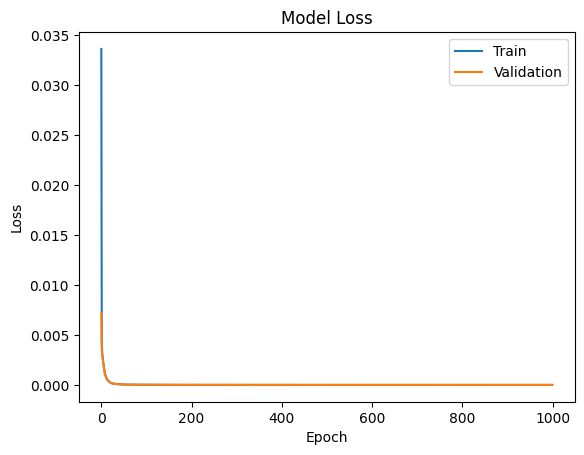

In [14]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

## Constrained neural network training

In [15]:
optimizer_cnn = Adam(learning_rate=0.0001)

In [16]:
random.set_seed(42)
cnn_model = Sequential([Input(shape=(input_dim, )), Dense(layer_neurons[0], activation=layer_activation[0])] 
                      + [Dense(layer_neurons[i], activation=layer_activation[i], kernel_constraint=non_neg) for i in range(1, 3)] 
                      + [Dense(output_dim, activation=output_activation, kernel_constraint=non_neg)]
                     )

cnn_model.compile(loss="mse", metrics=["mae"], optimizer=optimizer_cnn)
cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                      │ (None, 10)                  │              50 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 20)                  │             220 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 10)                  │             210 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 1)                   │              11 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 491 (1.92 KB)

 Trainable params: 491 (1.92 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
%%time 

cnn_history = cnn_model.fit(train_data[0], train_data[1], validation_data=val_data, epochs=epochs, batch_size=batch_size, verbose=0)

CPU times: total: 8min 49s
Wall time: 5min 25s


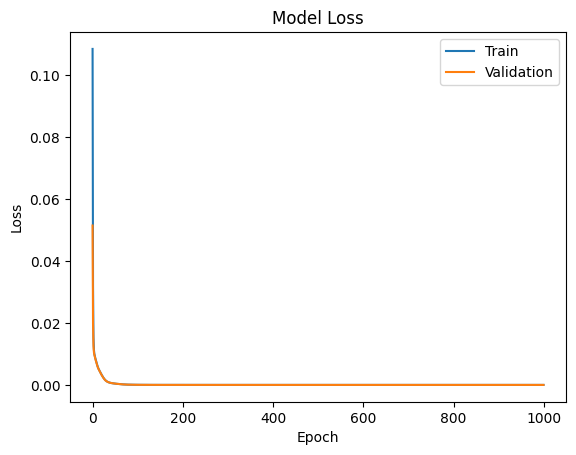

In [18]:
plt.plot(cnn_history.history['loss'])
plt.plot(cnn_history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

In [19]:
for layer in cnn_model.layers:

    weights = layer.get_weights()[0]
    print("All weights positive:", ~np.any(weights<0))

All weights positive: False
All weights positive: True
All weights positive: True
All weights positive: True


# Saving the models

In [705]:
import os

In [706]:
def makedir(path):
    if not os.path.exists(path):
        os.mkdir(path)
    return None

In [707]:
current_path = os.getcwd()
cwd = os.path.dirname(current_path)
unn_savepath = os.path.join(cwd, "NN models", "Unconstrained model")
cnn_savepath = os.path.join(cwd, "NN models", "Constrained model")

paths = [unn_savepath, cnn_savepath]

for path in paths:
    makedir(path)

In [708]:
# nn_model.save(os.path.join(unn_savepath, "Base_NN.keras"))
# cnn_model.save(os.path.join(cnn_savepath, "Base_NN.keras"))

In [709]:
min_max_scale_dict

{'x': {'min': 0.098, 'max': 19.541},
 'y': {'min': 0.1, 'max': 20.0},
 'a': {'min': 4.0, 'max': 8.0},
 'b': {'min': 0.25, 'max': 2.0},
 'z': {'min': 0.0, 'max': 741.868}}

## FICNN Model

In [310]:
random.set_seed(42)
nn_length = len(layer_neurons)
x_set = Input(shape=(input_dim, ), name="input_set")

h = Dense(layer_neurons[0], activation=layer_activation[0], name="W_0")(x_set)

for i in range(1, len(layer_neurons)):
    h_temp = Dense(layer_neurons[i], kernel_constraint=non_neg, name="W_pos_"+str(i))(h)
    x_temp = Dense(layer_neurons[i], name="W_"+str(i))(x_set)
    h_new = Add(name="layer_sum_"+str(i))([x_temp, h_temp])
    h = Activation(layer_activation[i], name="layer_output_"+str(i))(h_new)

h_temp = Dense(output_dim, kernel_constraint=non_neg, name="W_pos_"+str(nn_length))(h)
x_temp = Dense(output_dim, name="W_"+str(nn_length))(x_set)

y = Add(name="output_layer_temp")([x_temp, h_temp])
y = Activation(output_activation, name="output")(y)

ficnn_model = Model(x_set, y)
optimizer_ficnn = Adam(learning_rate=0.0001)
ficnn_model.compile(loss="mse", metrics=["mae"], optimizer=optimizer_ficnn)
ficnn_model.summary()

Model: "functional_20"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_set           │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ W_0 (Dense)         │ (None, 10)        │         50 │ input_set[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ W_1 (Dense)         │ (None, 20)        │        100 │ input_set[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ W_pos_1 (Dense)     │ (None, 20)        │        220 │ W_0[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_sum_1 (Add)   │ (None, 20)        │          0 │ W_1[0][0],        │
│                     │                   │            │ W_pos_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_output_1      │ (None, 20)        │          0 │ layer_sum_1[0][0] │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ W_2 (Dense)         │ (None, 10)        │         50 │ input_set[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ W_pos_2 (Dense)     │ (None, 10)        │        210 │ layer_output_1[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_sum_2 (Add)   │ (None, 10)        │          0 │ W_2[0][0],        │
│                     │                   │            │ W_pos_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_output_2      │ (None, 10)        │          0 │ layer_sum_2[0][0] │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ W_3 (Dense)         │ (None, 1)         │          5 │ input_set[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ W_pos_3 (Dense)     │ (None, 1)         │         11 │ layer_output_2[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_layer_temp   │ (None, 1)         │          0 │ W_3[0][0],        │
│ (Add)               │                   │            │ W_pos_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Activation) │ (None, 1)         │          0 │ output_layer_tem… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 646 (2.52 KB)

 Trainable params: 646 (2.52 KB)

 Non-trainable params: 0 (0.00 B)

In [311]:
%%time 

ficnn_history = ficnn_model.fit(train_data[0], train_data[1], validation_data=val_data, epochs=epochs, batch_size=batch_size, verbose=0)

CPU times: total: 1min 31s
Wall time: 6min 15s


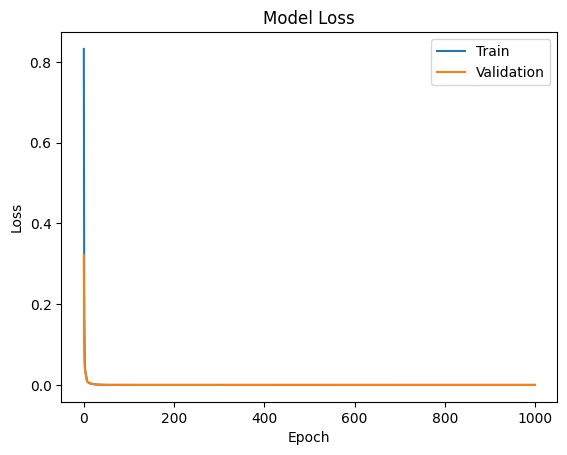

In [312]:
plt.plot(ficnn_history.history['loss'])
plt.plot(ficnn_history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

## PICNN Model

In [631]:
from tensorflow.keras import regularizers

l2_reg = regularizers.l2(1e-4)

In [672]:
layer_activation = ["relu"] * 3

In [688]:
random.set_seed(42)

x_con = Input(shape=(2,), name="input_convex")
x_ncon = Input(shape=(2,), name="input_nonconvex")

u = Dense(layer_neurons[0], activation=layer_activation[0], name="W_tilde_0")(x_ncon)

z_yu = Dense(units=2, name="W_yu_0")(x_ncon)
z_yu = Multiply(name="y_zyu_0")([x_con, z_yu])
z_yu = Dense(layer_neurons[0], use_bias=False, name="W_y_0")(z_yu)

z_u = Dense(layer_neurons[0], name="W_u_0")(x_ncon)

z = Add()([z_yu, z_u])
z = Activation(activation=layer_activation[0], name="z_0")(z)

for i in range(1, len(layer_neurons)):
    z_zu = Dense(units=layer_neurons[i-1], activation="relu", name="W_zu_"+str(i))(u)
    z_zu = Multiply(name="z_zzu_"+str(i))([z, z_zu])
    z_zu = Dense(layer_neurons[i], use_bias=False, kernel_constraint=non_neg, name="W_z_"+str(i))(z_zu)

    z_yu = Dense(units=2, name="W_yu_"+str(i))(u)
    z_yu = Multiply(name="y_zyu_"+str(i))([x_con, z_yu])
    z_yu = Dense(layer_neurons[i], use_bias=False, name="W_y_"+str(i))(z_yu)

    z_u = Dense(layer_neurons[i], name="W_u_"+str(i))(u)

    z = Add()([z_zu, z_yu, z_u])
    z = Activation(activation=layer_activation[i], name="z_"+str(i))(z)
    u = Dense(layer_neurons[i], activation=layer_activation[i], name="W_tilde_"+str(i))(u)

z_zu = Dense(units=layer_neurons[-1], activation="relu", name="W_zu_"+str(nn_length))(u)
z_zu = Multiply(name="z_zzu_out")([z, z_zu])
z_zu = Dense(output_dim, use_bias=False, kernel_constraint=non_neg, name="W_z_"+str(nn_length))(z_zu)

z_yu = Dense(units=2, name="W_yu_"+str(nn_length))(u)
z_yu = Multiply(name="y_zyu_out")([x_con, z_yu])
z_yu = Dense(output_dim, use_bias=False, name="W_y_"+str(nn_length))(z_yu)

z_u = Dense(output_dim, name="W_u_"+str(nn_length))(u)

z = Add()([z_zu, z_yu, z_u])
z = Activation(activation=output_activation, name="z_out")(z)

picnn_model = Model([x_con, x_ncon], z)
optimizer_picnn = Adam(learning_rate=0.0001)
picnn_model.compile(loss="mse", metrics=["mae"], optimizer=optimizer_picnn)
picnn_model.summary()

Model: "functional_28"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_nonconvex     │ (None, 2)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_convex        │ (None, 2)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ W_yu_0 (Dense)      │ (None, 2)         │          6 │ input_nonconvex[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ y_zyu_0 (Multiply)  │ (None, 2)         │          0 │ input_convex[0][… │
│                     │                   │            │ W_yu_0[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ W_y_0 (Dense)       │ (None, 10)        │         20 │ y_zyu_0[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ W_u_0 (Dense)       │ (None, 10)        │         30 │ input_nonconvex[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_61 (Add)        │ (None, 10)        │          0 │ W_y_0[0][0],      │
│                     │                   │            │ W_u_0[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ W_tilde_0 (Dense)   │ (None, 10)        │         30 │ input_nonconvex[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_0 (Activation)    │ (None, 10)        │          0 │ add_61[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ W_zu_1 (Dense)      │ (None, 10)        │        110 │ W_tilde_0[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ W_yu_1 (Dense)      │ (None, 2)         │         22 │ W_tilde_0[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_zzu_1 (Multiply)  │ (None, 10)        │          0 │ z_0[0][0],        │
│                     │                   │            │ W_zu_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ y_zyu_1 (Multiply)  │ (None, 2)         │          0 │ input_convex[0][… │
│                     │                   │            │ W_yu_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ W_z_1 (Dense)       │ (None, 20)        │        200 │ z_zzu_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ W_y_1 (Dense)       │ (None, 20)        │         40 │ y_zyu_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ W_u_1 (Dense)       │ (None, 20)        │        220 │ W_tilde_0[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_62 (Add)        │ (None, 20)        │          0 │ W_z_1[0][0],      │
│                     │                   │            │ W_y_1[0][0],      │
│                     │                   │            │ W_u_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ W_tilde_1 (Dense)   │ (None, 20)        │        220 │ W_tilde_0[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_1 (Activation)    │ (None, 20)        │          0 │ add_62[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ W_zu_2 (Dense)      │ (None, 20)        │        420 │ W_tilde_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ W_yu_2 (Dense)      │ (None, 2)         │         42 │ W_tilde_1[0][0] 

 Total params: 2,155 (8.42 KB)

 Trainable params: 2,155 (8.42 KB)

 Non-trainable params: 0 (0.00 B)

In [689]:
%%time 

picnn_history = picnn_model.fit([train_data[0][:, :2], train_data[0][:, 2:]], train_data[1], 
                                validation_data=([val_data[0][:, :2], val_data[0][:, 2:]], val_data[1]), 
                                epochs=epochs, batch_size=batch_size, verbose=0)

CPU times: total: 1min 27s
Wall time: 9min 54s


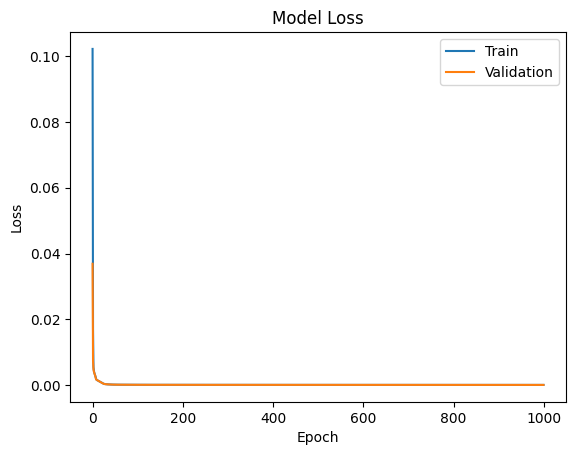

In [690]:
plt.plot(picnn_history.history['loss'])
plt.plot(picnn_history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

## FICNN and PICNN verification

In [691]:
# Import gurobi API and relevant functions

import gurobipy as gp
from gurobipy import GRB
from gurobi_ml import add_predictor_constr
import time as Time

In [692]:
def get_layer_data(model):
    weights_dict = {}
    for index, layer in enumerate(model.layers):
        weights = layer.get_weights()
        if weights:  # skip layers without weights
            layer_num = layer.name.split("_")[-1]
            prefix = layer.name.rsplit("_", 1)[0]
            if layer_num not in weights_dict.keys():
                weights_dict[layer_num] = {}
            weights_dict[layer_num][prefix] = weights 
    return weights_dict

In [693]:
weights_dict = get_layer_data(ficnn_model)

In [694]:
def _add_ficnn_variables(opt_model: gp.Model, time_steps: int, weights_dict):

    nn_layer_data = {}
    nn_variables = {}

    for layer_num, weights in weights_dict.items():
        nn_layer_data[layer_num] = {}
        nn_variables[layer_num] = {}
        for key, item in weights.items():
            nn_layer_data[layer_num][key] = item

        if "W_pos" not in weights.keys():
            nn_layer_data[layer_num]["input_size"] = nn_layer_data[layer_num]["W"][0].shape[0]
            nn_layer_data[layer_num]["output_size"] = nn_layer_data[layer_num]["W"][0].shape[1]
        else: 
            nn_layer_data[layer_num]["input_size"] = nn_layer_data[layer_num]["W_pos"][0].shape[0]
            nn_layer_data[layer_num]["output_size"] = nn_layer_data[layer_num]["W_pos"][0].shape[1]
        input_size = nn_layer_data[layer_num]["input_size"]
        output_size = nn_layer_data[layer_num]["output_size"]
        
        for time in range(time_steps):
            
            nn_variables[layer_num][time] = {"input_layer": opt_model.addMVar(input_size, vtype=GRB.CONTINUOUS, lb=-GRB.INFINITY, 
                                                                              name="Layer_"+str(layer_num)+"_T_"+str(time)+"_input"), 
                                            "affine_layer": opt_model.addMVar(output_size, vtype=GRB.CONTINUOUS, lb=-GRB.INFINITY, 
                                                                              name="Layer_"+str(layer_num)+"_T_"+str(time)+"_affine"),
                                            "output_layer": opt_model.addMVar(output_size, vtype=GRB.CONTINUOUS, lb=-GRB.INFINITY, 
                                                                              name="Layer_"+str(layer_num)+"_T_"+str(time)+"_output"),
                                            "penalty_cost": opt_model.addVar(vtype=GRB.CONTINUOUS, lb=0.0, 
                                                                             name="Layer_"+str(layer_num)+"_T_"+str(time)+"_penalty_cost")
                                            }
    opt_model.update()
    return nn_layer_data, nn_variables

In [695]:
def _affine_ficnn_transform(opt_model: gp.Model, layer_data, nn_decision_variables, nn_input_set):

    if "W_pos" not in layer_data.keys():
        opt_model.addConstr(nn_decision_variables["affine_layer"] 
                            == nn_decision_variables["input_layer"] @ layer_data["W"][0] + layer_data["W"][1])
    else:
        opt_model.addConstr(nn_decision_variables["affine_layer"] 
                            == nn_decision_variables["input_layer"] @ layer_data["W_pos"][0] + layer_data["W_pos"][1]
                               + nn_input_set @ layer_data["W"][0] + layer_data["W"][1])
    opt_model.update()
    
    return None

def _linear_func(opt_model: gp.Model, nn_decision_variables):

    opt_model.addConstr(nn_decision_variables["affine_layer"] 
                        == nn_decision_variables["output_layer"]) 
                        
    opt_model.addConstr(nn_decision_variables["penalty_cost"] == 0)

    opt_model.update()
    
    return None

def _relu_func(opt_model: gp.Model, nn_decision_variables, output_size: int, penalty_value: float):

    opt_model.addConstr(nn_decision_variables["output_layer"] >= nn_decision_variables["affine_layer"])

    opt_model.addConstrs(nn_decision_variables["output_layer"][i] >= 0 
                         for i in range(output_size)
                        )

    opt_model.addConstr(nn_decision_variables["penalty_cost"] == 0 * penalty_value)

    opt_model.update()

    return None 


In [696]:
model = gp.Model()
time_steps = 1 

        
model.setObjective(gp.quicksum(nn_variables["3"][time]["output_layer"] for time in range(time_steps)), sense=GRB.MINIMIZE)
        
        

In [697]:
model.optimize()

Gurobi Optimizer version 11.0.3 build v11.0.3rc0 (win64 - Windows 11.0 (22631.2))

CPU model: Intel(R) Core(TM) i7-10700T CPU @ 2.00GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 8 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 170 rows, 130 columns and 735 nonzeros
Model fingerprint: 0xb6fc3671
Coefficient statistics:
  Matrix range     [9e-10, 2e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [0e+00, 0e+00]
  RHS range        [9e-04, 8e-01]
Presolve removed 170 rows and 130 columns
Presolve time: 0.01s
Presolve: All rows and columns removed
Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    1.1784709e-03   0.000000e+00   0.000000e+00      0s

Solved in 0 iterations and 0.01 seconds (0.00 work units)
Optimal objective  1.178470894e-03


In [698]:
def _add_picnn_variables(opt_model: gp.Model, time_steps: int, weights_dict):

    nn_layer_data = {}
    nn_variables = {}

    for layer_num, weights in weights_dict.items():
        nn_layer_data[layer_num] = {}
        nn_variables[layer_num] = {}
        for key, item in weights.items():
            nn_layer_data[layer_num][key] = item

     
        nn_layer_data[layer_num]["input_size"] = nn_layer_data[layer_num]["W_u"][0].shape[0]
        nn_layer_data[layer_num]["output_size"] = nn_layer_data[layer_num]["W_u"][0].shape[1]
        
        input_size = nn_layer_data[layer_num]["input_size"]
        output_size = nn_layer_data[layer_num]["output_size"]

        
        for time in range(time_steps):
            
            nn_variables[layer_num][time] = {"input_layer": opt_model.addMVar(input_size, vtype=GRB.CONTINUOUS, lb=-GRB.INFINITY, 
                                                                               name="Layer_"+str(layer_num)+"_T_"+str(time)+"_input"),
                                             "affine_layer": opt_model.addMVar(output_size, vtype=GRB.CONTINUOUS, lb=-GRB.INFINITY, 
                                                                               name="Layer_"+str(layer_num)+"_T_"+str(time)+"_affine"),
                                             "output_layer": opt_model.addMVar(output_size, vtype=GRB.CONTINUOUS, lb=-GRB.INFINITY, 
                                                                               name="Layer_"+str(layer_num)+"_T_"+str(time)+"_output"),
                                             "penalty_cost": opt_model.addVar(vtype=GRB.CONTINUOUS, lb=0.0, 
                                                                              name="Layer_"+str(layer_num)+"_T_"+str(time)+"_penalty_cost")
                                            }
    opt_model.update()
    return nn_layer_data, nn_variables

In [699]:
def _u_linear_transform(u, weight_data):
    return u @ weight_data[0] + weight_data[1]

def _compute_affine_transform_weights(u, layer_data):
    z_u = _u_linear_transform(u, layer_data["W_u"])
    z_yu = _u_linear_transform(u, layer_data["W_yu"])
    
    if "W_zu" in layer_data.keys():
        z_zu = np.maximum(_u_linear_transform(u, layer_data["W_zu"]), 0)
    else:
        z_zu = [0]
    
    return {"z_u": z_u, "z_yu": z_yu, "z_zu": z_zu}

def _affine_picnn_transform(opt_model: gp.Model, layer_data, nn_decision_variables, nn_input_set, u):
    affine_weights = _compute_affine_transform_weights(u, layer_data)
    z_u = affine_weights["z_u"]
    z_yu = affine_weights["z_yu"]
    z_zu = affine_weights["z_zu"]
    
    if "W_z" not in layer_data.keys():
        opt_model.addConstr(nn_decision_variables["affine_layer"]
                            == (nn_decision_variables["input_layer"] * z_yu) @ layer_data["W_y"][0] + z_u)
    else:
        opt_model.addConstr(nn_decision_variables["affine_layer"]
                            == (nn_decision_variables["input_layer"] * z_zu) @ layer_data["W_z"][0] + z_u
                               + (nn_input_set * z_yu) @ layer_data["W_y"][0])
    opt_model.update()
    
    return None

In [700]:
model = gp.Model()
time_steps = 1 
weights_dict = get_layer_data(picnn_model)
nn_layer_data, nn_variables = _add_picnn_variables(model, time_steps, weights_dict)

input_vals = val_data[0][0]

for time in range(time_steps):
    # Set the input 
    u = input_vals[2:]
    model.addConstrs(nn_variables["0"][time]["input_layer"][i] == input_vals[i] for i in range(2))
    
    for layer_num, layer_data in nn_layer_data.items():
        output_size = layer_data["output_size"]
        nn_variable_set = nn_variables[layer_num][time]
        
        _affine_picnn_transform(model, layer_data, nn_variable_set, nn_variables["0"][time]["input_layer"], u)

        if layer_num != list(nn_layer_data.keys())[-1]:
            _relu_func(model, nn_variable_set, output_size , 1)
        else:
            _linear_func(model, nn_variable_set)

        if layer_num != list(nn_layer_data.keys())[-1]:  
            model.addConstr(nn_variables[layer_num][time]["output_layer"] 
                                    == nn_variables[str(int(layer_num) + 1)][time]["input_layer"])
            u = _u_linear_transform(u, layer_data["W_tilde"])
        
model.setObjective(gp.quicksum(nn_variables["3"][time]["output_layer"] for time in range(time_steps)), sense=GRB.MINIMIZE)

In [701]:
model.optimize()

Gurobi Optimizer version 11.0.3 build v11.0.3rc0 (win64 - Windows 11.0 (22631.2))

CPU model: Intel(R) Core(TM) i7-10700T CPU @ 2.00GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 8 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 168 rows, 128 columns and 412 nonzeros
Model fingerprint: 0xd522585a
Coefficient statistics:
  Matrix range     [2e-06, 6e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [0e+00, 0e+00]
  RHS range        [2e-03, 4e+00]
Presolve removed 168 rows and 128 columns
Presolve time: 0.00s
Presolve: All rows and columns removed
Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    3.9153516e+00   0.000000e+00   0.000000e+00      0s

Solved in 0 iterations and 0.00 seconds (0.00 work units)
Optimal objective  3.915351602e+00


In [702]:
picnn_model.predict([val_data[0][:, :2], val_data[0][:, 2:]])

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


array([[0.0015799 ],
       [0.03856764],
       [0.08798496],
       ...,
       [0.00965102],
       [0.02387299],
       [0.01821364]], dtype=float32)

## Save FICNN and PICNN models

In [723]:
ficnn_savepath = os.path.join(cwd, "NN models", "FICNN model")
makedir(ficnn_savepath)
ficnn_model.save(os.path.join(ficnn_savepath, "Base_FICNN.keras"))

weights_dict = get_layer_data(ficnn_model)
with open(os.path.join(ficnn_savepath, "Base_FICNN.pickle"), "wb") as f:
    pickle.dump(weights_dict, f)